
# Netflix Audience Rating Classification

### Auspify Technologies - Machine Learning Internship
### Task 3

This project develops a machine learning classification model
to predict the audience rating category of Netflix content
using available content attributes.

Author: B S Vanisha Babu


In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Saving Dataset.csv to Dataset (1).csv
Dataset loaded successfully!
Shape: (8790, 10)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
print("Rating Categories:")
print(df["rating"].value_counts())

Rating Categories:
rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


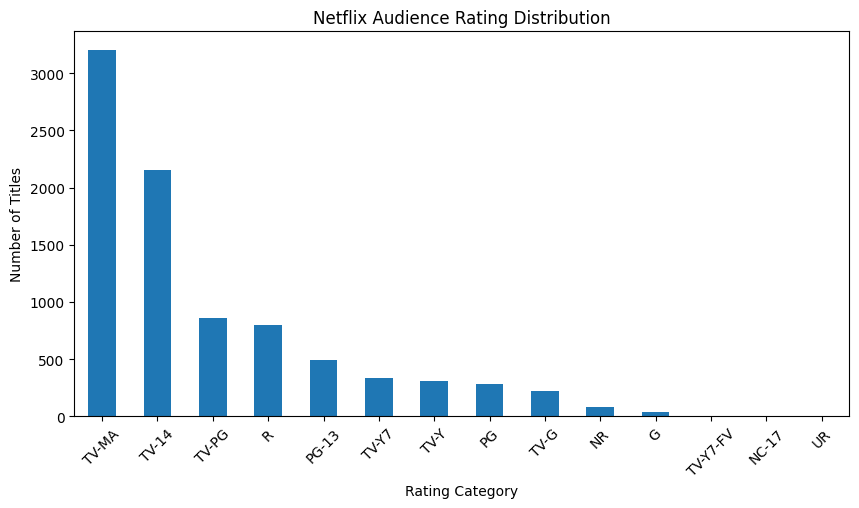

In [ ]:
import matplotlib.pyplot as plt

rating_counts = df["rating"].value_counts()

plt.figure(figsize=(10, 5))
rating_counts.plot(kind="bar")

plt.xlabel("Rating Category")
plt.ylabel("Number of Titles")
plt.title("Netflix Audience Rating Distribution")
plt.xticks(rotation=45)

plt.show()

### Rating Category Analysis

The dataset contains 14 different audience rating categories. TV-MA is the most common rating category, followed by TV-14 and TV-PG. Some categories such as TV-Y7-FV, NC-17, and UR have very few titles in comparison.

This indicates that the rating classes are not evenly distributed, so model evaluation should consider classification metrics such as precision, recall, and F1-score along with accuracy.

In [ ]:
print("Dataset Columns:")
print(df.columns.tolist())

Dataset Columns:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']


In [ ]:
# Select features and target

features = ["type", "country", "release_year", "duration", "listed_in"]

X = df[features]
y = df["rating"]

print("Selected Features:")
print(features)

print("\nTarget Variable:")
print("rating")

print("\nFeature Data Shape:", X.shape)
print("Target Data Shape:", y.shape)

Selected Features:
['type', 'country', 'release_year', 'duration', 'listed_in']

Target Variable:
rating

Feature Data Shape: (8790, 5)
Target Data Shape: (8790,)


In [ ]:
# Convert categorical features into numerical values

categorical_features = ["type", "country", "duration", "listed_in"]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=False
)

print("Encoded Feature Shape:", X_encoded.shape)
print("\nFirst 5 rows of encoded data:")
X_encoded.head()

Encoded Feature Shape: (8790, 822)

First 5 rows of encoded data:


,release_year,type_Movie,type_TV Show,country_Argentina,country_Australia,country_Austria,country_Bangladesh,country_Belarus,country_Belgium,country_Brazil,...,"listed_in_TV Dramas, TV Sci-Fi & Fantasy, Teen TV Shows","listed_in_TV Dramas, TV Thrillers","listed_in_TV Dramas, Teen TV Shows","listed_in_TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","listed_in_TV Horror, TV Mysteries, TV Thrillers","listed_in_TV Horror, TV Mysteries, Teen TV Shows","listed_in_TV Horror, Teen TV Shows","listed_in_TV Sci-Fi & Fantasy, TV Thrillers",listed_in_TV Shows,listed_in_Thrillers
0,2020,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2021,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2021,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2021,True,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,1993,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode the target variable
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Rating Categories:")
print(label_encoder.classes_)

print("\nEncoded Target Values:")
print(y_encoded[:10])

Rating Categories:
['G' 'NC-17' 'NR' 'PG' 'PG-13' 'R' 'TV-14' 'TV-G' 'TV-MA' 'TV-PG' 'TV-Y'
 'TV-Y7' 'TV-Y7-FV' 'UR']

Encoded Target Values:
[ 4  8  8  9  8  6  4 11  8 11]


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Data Shape: (7032, 822)
Testing Data Shape: (1758, 822)
Training Target Shape: (7032,)
Testing Target Shape: (1758,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create the Decision Tree model
decision_tree = DecisionTreeClassifier(
    random_state=42
)

# Train the model
decision_tree.fit(X_train, y_train)

# Make predictions
dt_predictions = decision_tree.predict(X_test)

# Calculate accuracy
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Accuracy (%):", round(dt_accuracy * 100, 2))

Decision Tree Accuracy: 0.45563139931740615
Decision Tree Accuracy (%): 45.56


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest.fit(X_train, y_train)

# Make predictions
rf_predictions = random_forest.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", round(rf_accuracy * 100, 2))

Random Forest Accuracy: 0.5102389078498294
Random Forest Accuracy (%): 51.02


In [ ]:
# Compare model accuracy

model_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy]
})

model_comparison["Accuracy (%)"] = (
    model_comparison["Accuracy"] * 100
).round(2)

print(model_comparison)

           Model  Accuracy  Accuracy (%)
0  Decision Tree  0.455631         45.56
1  Random Forest  0.510239         51.02


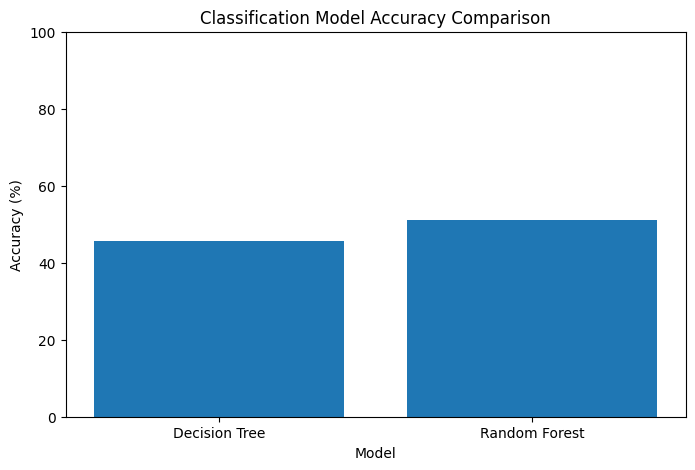

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Classification Model Accuracy Comparison")
plt.ylim(0, 100)

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameters for tuning
param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

# Create a Random Forest model for tuning
rf_tuning = RandomForestClassifier(
    random_state=42
)

# Perform Grid Search
grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(grid_search.best_score_ * 100, 2), "%")

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Best Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation Accuracy:
50.63 %


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameters for tuning
param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

# Create Random Forest model
rf_tuning = RandomForestClassifier(
    random_state=42
)

# Perform Grid Search using 2-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    cv=2,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(grid_search.best_score_ * 100, 2), "%")

Best Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 150}

Best Cross-Validation Accuracy:
49.6 %


In [ ]:
# Get the best tuned Random Forest model
tuned_random_forest = grid_search.best_estimator_

# Make predictions on the test data
tuned_rf_predictions = tuned_random_forest.predict(X_test)

# Calculate test accuracy
tuned_rf_accuracy = accuracy_score(
    y_test,
    tuned_rf_predictions
)

print("Tuned Random Forest Test Accuracy:", tuned_rf_accuracy)
print(
    "Tuned Random Forest Test Accuracy (%):",
    round(tuned_rf_accuracy * 100, 2)
)

Tuned Random Forest Test Accuracy: 0.5045506257110353
Tuned Random Forest Test Accuracy (%): 50.46


In [ ]:
from sklearn.metrics import classification_report

# Classification report for the Random Forest
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Random Forest Classification Report:

              precision    recall  f1-score   support

           G       1.00      0.62      0.77         8
       NC-17       0.00      0.00      0.00         1
          NR       0.00      0.00      0.00        16
          PG       0.59      0.40      0.48        57
       PG-13       0.45      0.40      0.42        98
           R       0.52      0.53      0.52       160
       TV-14       0.47      0.45      0.46       431
        TV-G       0.14      0.07      0.09        44
       TV-MA       0.58      0.71      0.64       641
       TV-PG       0.25      0.16      0.20       172
        TV-Y       0.51      0.52      0.52        61
       TV-Y7       0.50      0.43      0.46        67
    TV-Y7-FV       0.00      0.00      0.00         1
          UR       0.00      0.00      0.00         1

    accuracy                           0.51      1758
   macro avg       0.36      0.31      0.33      1758
weighted avg       0.49      0.51      0.4

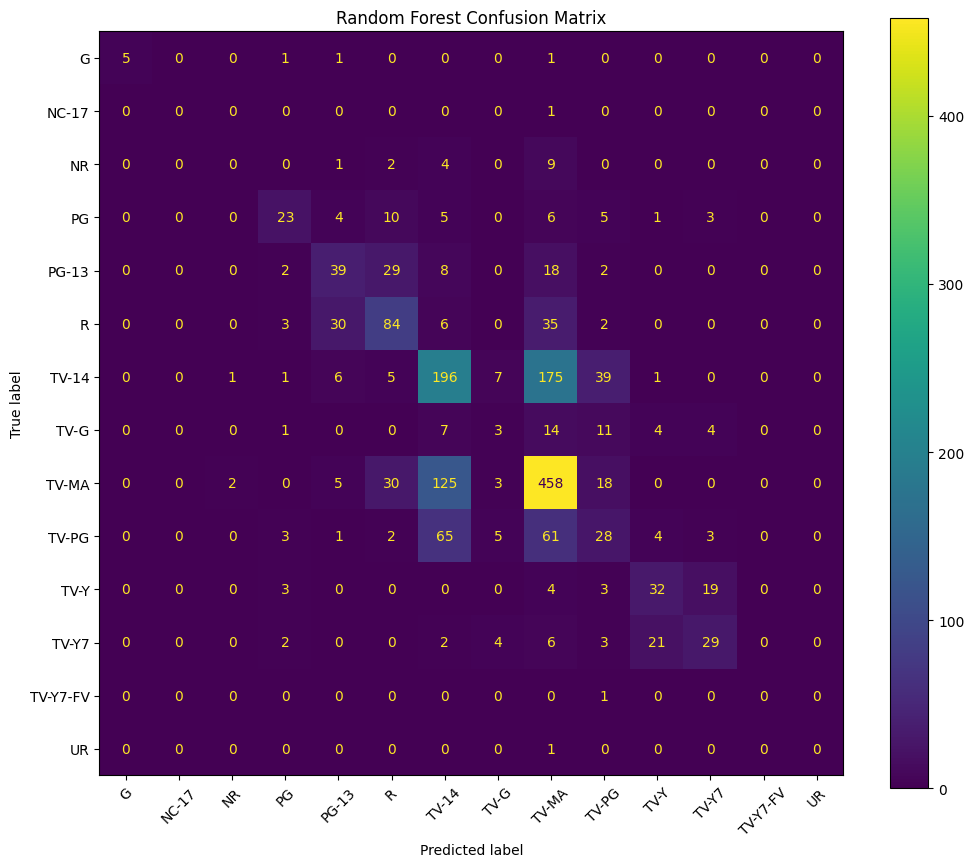

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, rf_predictions)

# Display confusion matrix
plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=plt.gca(),
    xticks_rotation=45
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
# Final model comparison

final_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy (%)": [
        round(dt_accuracy * 100, 2),
        round(rf_accuracy * 100, 2),
        round(tuned_rf_accuracy * 100, 2)
    ]
})

print("Final Model Comparison:")
print(final_comparison)

Final Model Comparison:
                 Model  Accuracy (%)
0        Decision Tree         45.56
1        Random Forest         51.02
2  Tuned Random Forest         50.46


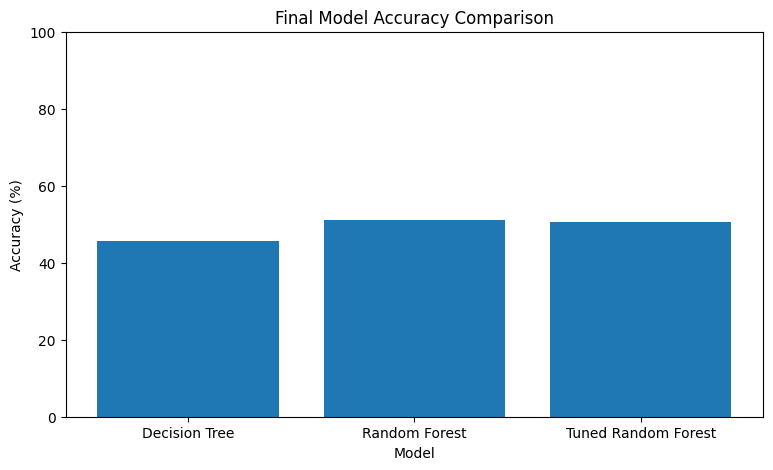

In [ ]:
# Visualize final model comparison

plt.figure(figsize=(9, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Final Model Accuracy Comparison")
plt.ylim(0, 100)

plt.show()

## Evaluation Summary

Three classification models were evaluated for predicting Netflix audience ratings.

The Decision Tree achieved an accuracy of 45.56%, while the original Random Forest achieved 51.02%. Hyperparameter tuning was then performed on the Random Forest using GridSearchCV. The tuned Random Forest achieved a test accuracy of 50.46%.

The original Random Forest produced the highest test accuracy among the three models in this experiment. However, the classification report showed that performance varied across rating categories, particularly because some rating classes contained very few samples.

Therefore, accuracy should be considered together with precision, recall, and F1-score when evaluating the model.

## Conclusion

In this project, a multi-class classification system was developed to predict Netflix audience rating categories from content attributes.

The dataset was analyzed, categorical features were encoded, and the data was divided into training and testing sets. Decision Tree and Random Forest classification models were trained and compared. Hyperparameter tuning was also performed using GridSearchCV.

The Random Forest achieved the highest test accuracy of 51.02% in this experiment. The evaluation using the classification report and confusion matrix also showed that model performance differed across the rating categories.

This project demonstrates the use of Decision Trees, Random Forest, classification metrics, model comparison, and hyperparameter tuning for a multi-class machine learning problem.